In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df= pd.read_csv('./Data_Set/Admission_Predict_Ver1.1.csv')

In [8]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
df.isnull()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [11]:
df.shape

(500, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [22]:
df.drop(columns=['Serial No.'],inplace=True)

Scaled the columns

In [23]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [30]:
X=df.iloc[:,0:-1]
X.shape

(500, 7)

In [35]:

y=df.iloc[:,-1]
y.shape

(500,)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [42]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [44]:
X_train_scaled.shape

(400, 7)

In [45]:
X_test_scaled.shape

(100, 7)

In [46]:
X_train_scaled

array([[0.16      , 0.22222222, 0.        , ..., 0.5       , 0.21153846,
        0.        ],
       [0.62      , 0.66666667, 1.        , ..., 1.        , 0.84935897,
        1.        ],
       [0.52      , 0.44444444, 0.5       , ..., 0.625     , 0.61858974,
        0.        ],
       ...,
       [0.84      , 0.92592593, 1.        , ..., 1.        , 0.85576923,
        1.        ],
       [0.74      , 0.66666667, 0.75      , ..., 0.875     , 0.70512821,
        1.        ],
       [0.7       , 0.62962963, 0.75      , ..., 0.75      , 0.59935897,
        1.        ]])

In [48]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [49]:
model=Sequential()

For regression problem in output layer the activation function is linear

In [50]:
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(1,activation='linear'))

c:\Users\R.C\.conda\envs\Deep_Learning\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [55]:
history=model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.8404 - val_loss: 1.7808
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1.5146 - val_loss: 1.4528
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.2635 - val_loss: 1.1658
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0401 - val_loss: 0.9177
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8393 - val_loss: 0.7079
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5960 - val_loss: 0.5367
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4841 - val_loss: 0.3951
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3267 - val_loss: 0.2802
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2439 - val_loss: 0.1837
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1459 - val_loss: 0.1055


In [57]:
y_pred=model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


In [58]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

-6.019521178593663

In [59]:
import matplotlib.pyplot as plt

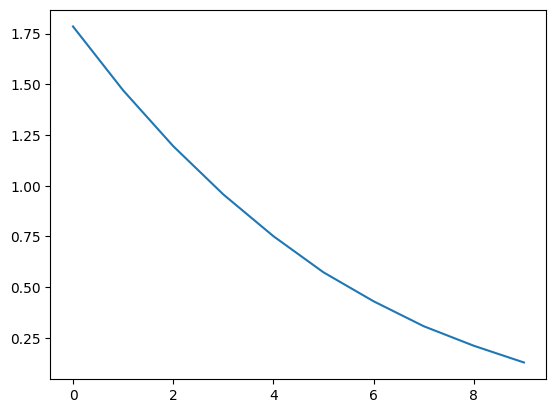

In [60]:
plt.plot(history.history['loss'])